# **Assignment 3: PASCAL VOC 2007 Object Detection**

In this project, we use the PASCAL VOC 2007 dataset for **object detection**.

The dataset has been divided into training, validation, and test sets using the official VOC split files.

Students should use:
- train.txt for training
- val.txt for validation
- test.txt for final testing



The images are stored in JPEGImages.

The object detection annotations are stored in Annotations.

Each annotation file is an XML file that contains object class names and bounding-box coordinates.

**The code below prepares the dataset for this assignment.**

Please run the following code cells before starting your implementation.

### **1. Download and extract the dataset**


In [1]:
!wget -q http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
!wget -q http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtest_06-Nov-2007.tar

# Extract files
!tar -xf VOCtrainval_06-Nov-2007.tar
!tar -xf VOCtest_06-Nov-2007.tar

### **2. Check the dataset structure**

In [2]:
# Check the main VOC2007 folder

!ls VOCdevkit/VOC2007

Annotations  ImageSets	JPEGImages  SegmentationClass  SegmentationObject


##### **For this object detection project, we mainly use:**


*   JPEGImages         # image files
*   Annotations         # XML annotation files with bounding boxes
*   ImageSets/Main       # train/validation/test split files

### **3. Define dataset paths**

In [3]:
import os

VOC_ROOT = "VOCdevkit/VOC2007"

IMAGE_DIR = os.path.join(VOC_ROOT, "JPEGImages")
ANNOTATION_DIR = os.path.join(VOC_ROOT, "Annotations")
SPLIT_DIR = os.path.join(VOC_ROOT, "ImageSets", "Main")

print("Image folder:", IMAGE_DIR)
print("Annotation folder:", ANNOTATION_DIR)
print("Split folder:", SPLIT_DIR)

Image folder: VOCdevkit/VOC2007/JPEGImages
Annotation folder: VOCdevkit/VOC2007/Annotations
Split folder: VOCdevkit/VOC2007/ImageSets/Main


###**4. Load train, validation, and test image IDs**

PASCAL VOC provides official split files.
Each line is an image ID, such as 000005, which corresponds to:


*   JPEGImages/000005.jpg
*   Annotations/000005.xml

In [9]:
def load_image_ids(split_name):
    split_file = os.path.join(SPLIT_DIR, f"{split_name}.txt")

    with open(split_file, "r") as f:
        image_ids = [line.strip() for line in f.readlines()]

    return image_ids


train_ids = load_image_ids("train")
val_ids = load_image_ids("val")
test_ids = load_image_ids("test")

print("Number of training images:", len(train_ids))
print("Number of validation images:", len(val_ids))
print("Number of test images:", len(test_ids))

Number of training images: 2501
Number of validation images: 2510
Number of test images: 4952


### **5. Define VOC classes**





In [5]:
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

print("Number of classes:", len(VOC_CLASSES))
print(VOC_CLASSES)

Number of classes: 20
['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


### **6. Read XML annotation**

In [6]:
import xml.etree.ElementTree as ET

def read_voc_annotation(image_id):
    """
    Read annotation information for one image.

    Returns:
        objects: a list of dictionaries.
        Each dictionary contains class name and bounding box.
    """

    xml_path = os.path.join(ANNOTATION_DIR, image_id + ".xml")

    tree = ET.parse(xml_path)
    root = tree.getroot()

    objects = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        bndbox = obj.find("bndbox")
        xmin = int(float(bndbox.find("xmin").text))
        ymin = int(float(bndbox.find("ymin").text))
        xmax = int(float(bndbox.find("xmax").text))
        ymax = int(float(bndbox.find("ymax").text))

        objects.append({
            "class_name": class_name,
            "bbox": [xmin, ymin, xmax, ymax]
        })

    return objects

### **7. Print one sample annotation**

In [7]:
sample_id = train_ids[0]

print("Image ID:", sample_id)
print("Image path:", os.path.join(IMAGE_DIR, sample_id + ".jpg"))
print("Annotation path:", os.path.join(ANNOTATION_DIR, sample_id + ".xml"))

objects = read_voc_annotation(sample_id)

print("Objects:")
for obj in objects:
    print(obj)

Image ID: 000012
Image path: VOCdevkit/VOC2007/JPEGImages/000012.jpg
Annotation path: VOCdevkit/VOC2007/Annotations/000012.xml
Objects:
{'class_name': 'car', 'bbox': [156, 97, 351, 270]}


### **8. Visualize two samples with bounding boxes**

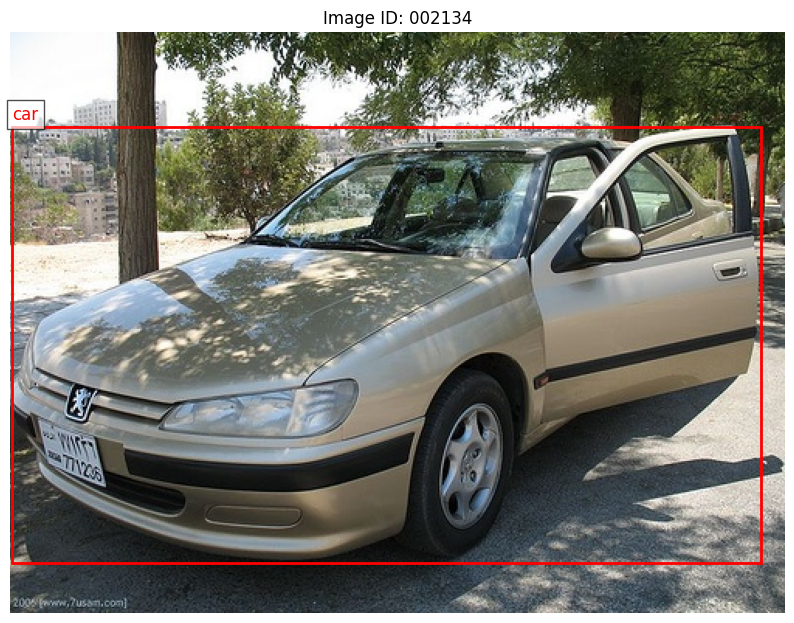

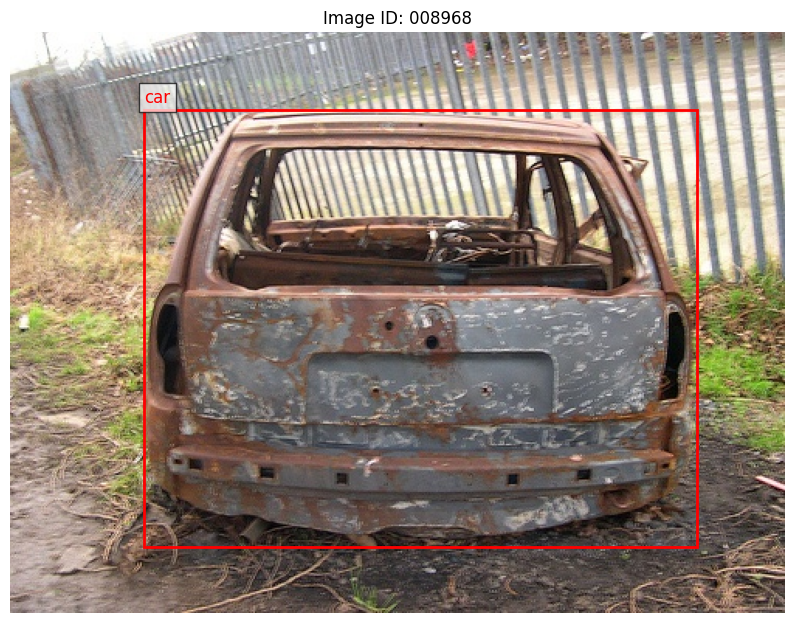

In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def visualize_sample(image_id):
    """
    Visualize one image with ground-truth bounding boxes.
    """

    image_path = os.path.join(IMAGE_DIR, image_id + ".jpg")
    image = Image.open(image_path).convert("RGB")

    objects = read_voc_annotation(image_id)

    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(image)

    for obj in objects:
        class_name = obj["class_name"]
        xmin, ymin, xmax, ymax = obj["bbox"]

        width = xmax - xmin
        height = ymax - ymin

        rect = patches.Rectangle(
            (xmin, ymin),
            width,
            height,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

        ax.text(
            xmin,
            ymin - 5,
            class_name,
            fontsize=12,
            color="red",
            bbox=dict(facecolor="white", alpha=0.7)
        )

    ax.set_title(f"Image ID: {image_id}")
    ax.axis("off")
    plt.show()


# Visualize two random training samples
sample_ids = random.sample(train_ids, 2)

for image_id in sample_ids:
    visualize_sample(image_id)

If the code runs correctly, two example images will be displayed with their bounding boxes and class labels.

## **Task 1: Object Detection Network Design**

In this task, you are required to design and train an object detection network using the PASCAL VOC 2007 dataset. The objective is to detect objects in images and predict both their class labels and bounding boxes.

You may build your model based on any suitable object detection architecture, such as YOLO, SSD, Faster R-CNN, RetinaNet, or other related models. You are also allowed to use or refer to existing architectures and open-source implementations. However, directly using an unchanged pre-trained model or simply running an official tutorial is not sufficient.

You must customize the model architecture and/or training pipeline to make it suitable for this assignment task. Possible customization may include, but is not limited to, modifying the backbone network, changing the detection head, adjusting anchor settings, freezing or unfreezing different layers, or designing other reasonable improvements.

The model performance should be evaluated using mAP@0.5 on the test set. A model achieving mAP@0.5 ≥ 60% will be considered to have met the performance requirement.

You should clearly explain your model design, training strategy, customization, and evaluation results in your (this) report. Your mark will not be determined by mAP alone. The correctness of the implementation, justification of the design choices, result visualization, and error analysis will also be considered.

In [10]:
# Code starts here

## **Task 2: Detection Performance and Error Analysis**

Based on the object detection model developed in Task 1, you are required to conduct a detailed performance and error analysis to better understand the behaviour of your model.

Your analysis should include the following components:

1. Class-wise performance analysis

Report the AP or other appropriate detection performance metric for each object category. Identify which classes achieve better performance and which classes are more difficult for your model to detect.

2. Error case visualization

Visualize at least five representative failure cases from your detection results. Each example should clearly show the input image, ground-truth bounding boxes, predicted bounding boxes, predicted class labels, and confidence scores where applicable.

3. Error type discussion and potential solutions

Discuss the possible causes of the observed detection errors, such as missed detections, false positives, inaccurate bounding boxes, class confusion, small objects, occlusion, complex backgrounds, or class imbalance. You should also discuss possible solutions or improvements.

In [11]:
# Code starts here

**All code implementation, experimental results, and written discussion must be completed within this notebook.**

**Please save your final work as an .ipynb file and submit.**

## **Marking rubric**
The Assignment 3 is totally 50 marks.

**Report Submission — 25 marks.**

Task 1: Object Detection Network Design — 17 marks

(Model implementation:5, Model / training pipeline customization and discussion :10,Performance:2)

Task 2: Detection Performance and Error Analysis — 8 marks

(Class-wise performance analysis:3, Error case visualization and discussion:3, Potential solutions:2)



**Oral Question — 25 marks**

Each group will be asked some questions in week 13.
